# 0. Objetivo

Este notebook implementa el componente de forecasting del MVP del Asistente Inteligente para Planeación de Costos Operativos.

Su propósito es validar un modelo ARIMA mediante una partición temporal, reentrenarlo utilizando el histórico completo y generar el forecast oficial que será consumido por la Forecast Tool del asistente.

# 1. Preparación

Se importan las librerías, se configuran las rutas del proyecto y se carga el conjunto de datos que será utilizado durante el proceso de entrenamiento y generación de pronósticos.

In [49]:
from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [50]:
df = pd.read_csv(
    DATA_PROCESSED / "historico_equipos_limpio.csv",
    parse_dates=["Date"]
).sort_values("Date")

df.head()

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


# 2. Validación temporal

Antes de generar el forecast oficial del MVP, se evalúa el desempeño del modelo mediante una partición temporal del histórico.

Esta validación permite estimar la capacidad del modelo para predecir observaciones no utilizadas durante el entrenamiento y verificar que su desempeño sea adecuado antes de construir el modelo operativo definitivo.

## 2.1 División temporal del histórico

El conjunto de datos se divide respetando el orden cronológico de la serie temporal.

El período anterior a la fecha de corte se utiliza para entrenar el modelo, mientras que el período posterior se reserva para validar su capacidad predictiva sobre datos no observados.

In [51]:
fecha_corte = pd.Timestamp("2023-01-01")

train_df = df[df["Date"] < fecha_corte].copy()
test_df = df[df["Date"] >= fecha_corte].copy()

train_df.shape, test_df.shape

((3358, 6), (172, 6))

In [52]:
resumen_particion = pd.DataFrame([
    {
        "Conjunto": "Entrenamiento",
        "Filas": len(train_df),
        "Fecha_inicio": train_df["Date"].min(),
        "Fecha_fin": train_df["Date"].max(),
    },
    {
        "Conjunto": "Prueba",
        "Filas": len(test_df),
        "Fecha_inicio": test_df["Date"].min(),
        "Fecha_fin": test_df["Date"].max(),
    },
])

resumen_particion["Porcentaje_%"] = (
    resumen_particion["Filas"] / len(df) * 100
).round(2)

resumen_particion

,Conjunto,Filas,Fecha_inicio,Fecha_fin,Porcentaje_%
0,Entrenamiento,3358,2010-01-04,2022-12-30,95.13
1,Prueba,172,2023-01-03,2023-08-31,4.87


### Hallazgo

La partición temporal separa correctamente el histórico en un conjunto de entrenamiento y un conjunto de prueba.

El modelo será entrenado con observaciones comprendidas entre 2010-01-04 y 2022-12-30, mientras que su desempeño será evaluado sobre el período 2023-01-03 a 2023-08-31.

Esta separación evita fuga de información y permite validar el comportamiento predictivo del modelo en un escenario equivalente a estimar valores futuros a partir de información histórica disponible.

## 2.2 Entrenamiento ARIMA para Equipo 1

Se entrena un modelo ARIMA utilizando únicamente el conjunto de entrenamiento.

Este modelo permitirá generar predicciones sobre el período de prueba y evaluar si la metodología es adecuada antes de construir el modelo operativo definitivo.

In [53]:
ARIMA_ORDER = (1, 1, 1)

serie_train_equipo1 = train_df["Price_Equipo1"].astype(float).reset_index(drop=True)

modelo_equipo1_validacion = ARIMA(
    serie_train_equipo1,
    order=ARIMA_ORDER
).fit()

modelo_equipo1_validacion.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          Price_Equipo1   No. Observations:                 3358
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -12888.950
Date:                Tue, 30 Jun 2026   AIC                          25783.900
Time:                        22:12:27   BIC                          25802.256
Sample:                             0   HQIC                         25790.465
                               - 3358                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0387      0.029     -1.323      0.186      -0.096       0.019
ma.L1         -0.4586      0.025    -18.176      0.000      -0.508      -0.409
sigma2       126.6484      2.203     57.485      0.000     122.330     130.966
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               639.45
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               1.24   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

El modelo ARIMA para Equipo 1 fue entrenado utilizando únicamente el conjunto de entrenamiento.

La validación del desempeño se realizará en la siguiente etapa mediante la comparación entre los valores pronosticados y los valores reales del período de prueba.

## 2.3 Predicción sobre el período de prueba - Equipo 1

Con el modelo entrenado sobre el conjunto de entrenamiento, se generan predicciones para el mismo número de observaciones disponibles en el conjunto de prueba.

Estas predicciones permitirán comparar el comportamiento estimado por el modelo contra los valores reales observados.

In [54]:
forecast_equipo1_validacion = modelo_equipo1_validacion.get_forecast(
    steps=len(test_df)
)

pred_equipo1 = forecast_equipo1_validacion.predicted_mean.reset_index(drop=True)
conf_equipo1 = forecast_equipo1_validacion.conf_int().reset_index(drop=True)

validacion_equipo1 = pd.DataFrame({
    "Date": test_df["Date"].reset_index(drop=True),
    "Real": test_df["Price_Equipo1"].reset_index(drop=True),
    "Forecast": pred_equipo1,
    "Lower": conf_equipo1.iloc[:, 0],
    "Upper": conf_equipo1.iloc[:, 1],
})

validacion_equipo1.head()

,Date,Real,Forecast,Lower,Upper
0,2023-01-03,501.93,490.537768,468.480695,512.594840
1,2023-01-04,504.99,490.505769,465.817790,515.193748
2,2023-01-05,506.72,490.507006,463.266205,517.747806
3,2023-01-06,493.40,490.506958,460.939256,520.074659
4,2023-01-09,517.84,490.506960,458.782343,522.231576


## 2.4 Métricas de validación - Equipo 1

Se calculan métricas de error para comparar los valores pronosticados por el modelo ARIMA contra los valores reales observados en el conjunto de prueba.

Estas métricas permiten evaluar si el modelo tiene un desempeño suficientemente estable para ser considerado como base del forecast operativo.

In [55]:
validacion_equipo1["Error"] = (
    validacion_equipo1["Real"] - validacion_equipo1["Forecast"]
)

validacion_equipo1["Error_abs"] = validacion_equipo1["Error"].abs()

validacion_equipo1["Error_%"] = (
    validacion_equipo1["Error_abs"] / validacion_equipo1["Real"] * 100
)

metricas_equipo1_validacion = pd.DataFrame([
    {
        "Equipo": "Equipo 1",
        "MAE": validacion_equipo1["Error_abs"].mean(),
        "RMSE": np.sqrt((validacion_equipo1["Error"] ** 2).mean()),
        "MAPE_%": validacion_equipo1["Error_%"].mean(),
        "Cobertura_IC_%": (
            (
                validacion_equipo1["Real"].between(
                    validacion_equipo1["Lower"],
                    validacion_equipo1["Upper"]
                )
            ).mean() * 100
        ),
    }
]).round(2)

metricas_equipo1_validacion

,Equipo,MAE,RMSE,MAPE_%,Cobertura_IC_%
0,Equipo 1,31.59,34.92,6.55,98.26


### Hallazgo

El modelo ARIMA(1,1,1) aplicado al Equipo 1 presenta un desempeño aceptable durante la validación temporal.

En el período de prueba, el modelo obtiene un MAPE de 6.55 %, lo que indica un error porcentual promedio moderado para un escenario de forecasting de costos operativos.

La cobertura del intervalo de confianza alcanza 98.26 %, mostrando que la mayoría de los valores reales observados se encuentran dentro del rango estimado por el modelo.

Aunque el pronóstico puntual tiende a ser conservador y relativamente estable, las métricas obtenidas respaldan su uso como candidato para el forecast operativo del MVP.

## 2.5 Visualización de validación - Equipo 1

Se compara visualmente la serie real del período de prueba contra el pronóstico generado por el modelo ARIMA.

Esta visualización permite complementar las métricas numéricas y observar si el modelo reproduce adecuadamente la trayectoria general del costo.

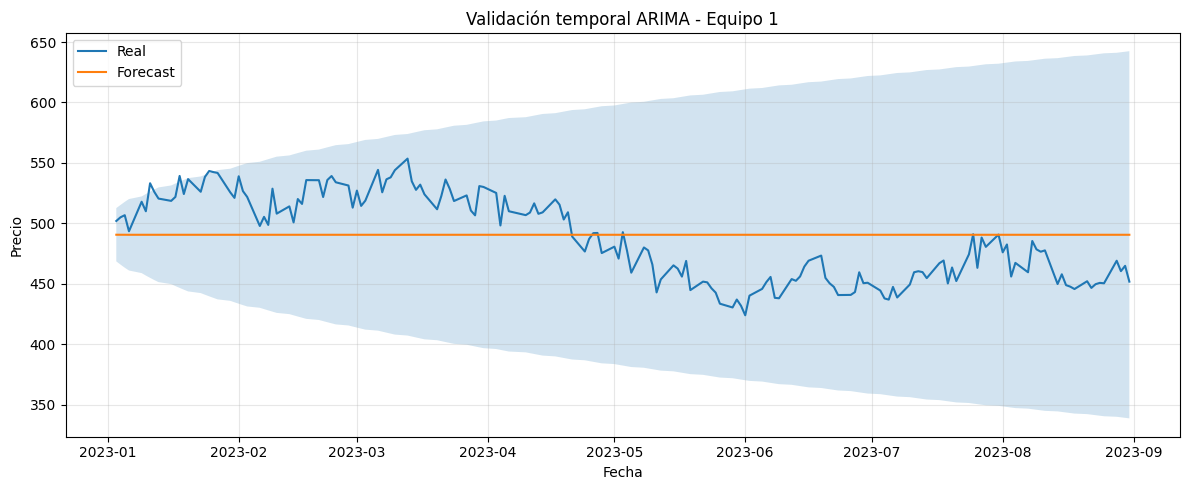

In [56]:
plt.figure(figsize=(12, 5))

plt.plot(
    validacion_equipo1["Date"],
    validacion_equipo1["Real"],
    label="Real"
)

plt.plot(
    validacion_equipo1["Date"],
    validacion_equipo1["Forecast"],
    label="Forecast"
)

plt.fill_between(
    validacion_equipo1["Date"],
    validacion_equipo1["Lower"],
    validacion_equipo1["Upper"],
    alpha=0.2
)

plt.title("Validación temporal ARIMA - Equipo 1")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Hallazgo

La visualización de validación del Equipo 1 muestra que el pronóstico puntual generado por ARIMA tiende a mantenerse estable durante el período de prueba.

Aunque el modelo no reproduce completamente las variaciones de corto plazo observadas en la serie real, el intervalo de incertidumbre cubre la mayor parte de los valores observados.

Este comportamiento respalda el uso del modelo como una aproximación conservadora para el forecast operativo del MVP, siempre que sus resultados sean comunicados junto con el rango de incertidumbre correspondiente.

## 2.6 Entrenamiento ARIMA para Equipo 2

Se entrena un modelo ARIMA utilizando únicamente el conjunto de entrenamiento del Equipo 2.

Este modelo será evaluado posteriormente sobre el período de prueba para determinar si puede utilizarse como base del forecast operativo del MVP.

In [57]:
serie_train_equipo2 = train_df["Price_Equipo2"].astype(float).reset_index(drop=True)

modelo_equipo2_validacion = ARIMA(
    serie_train_equipo2,
    order=ARIMA_ORDER
).fit()

modelo_equipo2_validacion.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          Price_Equipo2   No. Observations:                 3358
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -15154.544
Date:                Tue, 30 Jun 2026   AIC                          30315.087
Time:                        22:12:27   BIC                          30333.444
Sample:                             0   HQIC                         30321.652
                               - 3358                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0041      0.026      0.157      0.876      -0.048       0.056
ma.L1         -0.5166      0.020    -25.213      0.000      -0.557      -0.476
sigma2       488.1562      8.817     55.368      0.000     470.876     505.436
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               486.75
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.39   Skew:                             0.06
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

El modelo ARIMA(1,1,1) para Equipo 2 fue entrenado correctamente utilizando únicamente el conjunto de entrenamiento.

El ajuste muestra que el componente de media móvil tiene relevancia estadística dentro del modelo, mientras que el componente autorregresivo de primer orden no presenta una contribución significativa en esta especificación.

Las pruebas diagnósticas iniciales no evidencian autocorrelación fuerte inmediata en los residuos, aunque sí sugieren desviaciones respecto a normalidad y varianza constante.

Esta etapa confirma que el modelo puede ser utilizado para generar predicciones sobre el período de prueba. La calidad predictiva será evaluada posteriormente mediante métricas de error y comparación visual contra los valores reales observados.

## 2.7 Predicción sobre el período de prueba - Equipo 2

Con el modelo ARIMA entrenado para el Equipo 2, se generan predicciones para el mismo número de observaciones disponibles en el conjunto de prueba.

Estas predicciones serán utilizadas posteriormente para comparar el valor estimado por el modelo contra el valor real observado.

In [58]:
forecast_equipo2_validacion = modelo_equipo2_validacion.get_forecast(
    steps=len(test_df)
)

pred_equipo2 = forecast_equipo2_validacion.predicted_mean.reset_index(drop=True)
conf_equipo2 = forecast_equipo2_validacion.conf_int().reset_index(drop=True)

validacion_equipo2 = pd.DataFrame({
    "Date": test_df["Date"].reset_index(drop=True),
    "Real": test_df["Price_Equipo2"].reset_index(drop=True),
    "Forecast": pred_equipo2,
    "Lower": conf_equipo2.iloc[:, 0],
    "Upper": conf_equipo2.iloc[:, 1],
})

validacion_equipo2.head()

,Date,Real,Forecast,Lower,Upper
0,2023-01-03,983.65,1008.671935,965.367985,1051.975884
1,2023-01-04,978.30,1008.686746,960.509308,1056.864185
2,2023-01-05,981.13,1008.686808,956.122352,1061.251263
3,2023-01-06,998.95,1008.686808,952.074421,1065.299195
4,2023-01-09,1038.08,1008.686808,948.297217,1069.076399


Se generaron correctamente las predicciones del Equipo 2 para el período de prueba.

La tabla permite comparar, para cada fecha de validación, el valor real observado, el valor estimado por el modelo ARIMA y el intervalo de incertidumbre asociado.

En las primeras observaciones, el pronóstico puntual se mantiene alrededor de 1008.68, mientras que los valores reales presentan variaciones por encima y por debajo de ese nivel. Por esta razón, todavía no se puede concluir si el desempeño del modelo es adecuado únicamente a partir de esta tabla.

La calidad predictiva del modelo será evaluada en la siguiente etapa mediante métricas de error y cobertura del intervalo de confianza.

## 2.8 Métricas de validación - Equipo 2

Se calculan métricas de error para evaluar el desempeño del modelo ARIMA del Equipo 2 sobre el período de prueba.

Estas métricas permiten comparar el pronóstico generado por el modelo contra los valores reales observados y determinar si el desempeño es adecuado para el MVP.

In [59]:
validacion_equipo2["Error"] = (
    validacion_equipo2["Real"] - validacion_equipo2["Forecast"]
)

validacion_equipo2["Error_abs"] = validacion_equipo2["Error"].abs()

validacion_equipo2["Error_%"] = (
    validacion_equipo2["Error_abs"] / validacion_equipo2["Real"] * 100
)

metricas_equipo2_validacion = pd.DataFrame([
    {
        "Equipo": "Equipo 2",
        "MAE": validacion_equipo2["Error_abs"].mean(),
        "RMSE": np.sqrt((validacion_equipo2["Error"] ** 2).mean()),
        "MAPE_%": validacion_equipo2["Error_%"].mean(),
        "Cobertura_IC_%": (
            validacion_equipo2["Real"].between(
                validacion_equipo2["Lower"],
                validacion_equipo2["Upper"]
            ).mean() * 100
        ),
    }
]).round(2)

metricas_equipo2_validacion

,Equipo,MAE,RMSE,MAPE_%,Cobertura_IC_%
0,Equipo 2,52.75,63.07,5.47,97.09


### Hallazgo

El modelo ARIMA(1,1,1) aplicado al Equipo 2 presenta un desempeño adecuado durante la validación temporal.

En el período de prueba, el modelo obtiene un MAPE de 5.47 %, lo que indica un error porcentual promedio bajo para un escenario de forecasting de costos operativos.

El MAE de 52.75 y el RMSE de 63.07 deben interpretarse considerando que el Equipo 2 maneja una escala de precios superior a la del Equipo 1. Por esta razón, el MAPE resulta especialmente útil para evaluar el desempeño relativo del modelo.

La cobertura del intervalo de confianza alcanza 97.09 %, lo que muestra que la mayoría de los valores reales observados se encuentran dentro del rango estimado por el modelo.

Estos resultados respaldan el uso del modelo ARIMA como candidato válido para construir el forecast operativo del Equipo 2 dentro del MVP.

## 2.9 Síntesis de validación temporal

Se consolidan las métricas de validación de ambos equipos para comparar el desempeño del modelo ARIMA durante el período de prueba.

Esta síntesis permite decidir si el modelo es suficientemente estable para ser reentrenado con el histórico completo y utilizado como base del forecast operativo del MVP.

In [60]:
metricas_validacion = pd.concat(
    [
        metricas_equipo1_validacion,
        metricas_equipo2_validacion,
    ],
    ignore_index=True,
)

metricas_validacion

,Equipo,MAE,RMSE,MAPE_%,Cobertura_IC_%
0,Equipo 1,31.59,34.92,6.55,98.26
1,Equipo 2,52.75,63.07,5.47,97.09


### Hallazgo

La validación temporal muestra que el modelo ARIMA(1,1,1) presenta un desempeño aceptable para ambos equipos durante el período de prueba.

El Equipo 1 obtiene un MAPE de 6.55 %, mientras que el Equipo 2 obtiene un MAPE de 5.47 %. Estos niveles de error porcentual indican que el modelo logra aproximar el comportamiento futuro de los costos con un margen de error moderado para el contexto del MVP.

Además, ambos equipos presentan una alta cobertura del intervalo de confianza: 98.26 % para Equipo 1 y 97.09 % para Equipo 2. Esto indica que la mayoría de los valores reales observados durante el período de prueba se ubicaron dentro del rango estimado por el modelo.

Con base en estos resultados, ARIMA puede ser utilizado como modelo candidato para generar los pronósticos operativos del asistente, siempre que las respuestas del agente incluyan tanto el valor esperado como el rango de incertidumbre asociado.

# 3. Modelo operativo

Una vez validado el desempeño del modelo ARIMA mediante la partición temporal, se reentrena el modelo utilizando el 100 % del histórico disponible.

Este modelo operativo será la base para generar los pronósticos oficiales del MVP que posteriormente serán consumidos por la Forecast Tool del asistente.

In [61]:
serie_operativa_equipo1 = df["Price_Equipo1"].astype(float).reset_index(drop=True)
serie_operativa_equipo2 = df["Price_Equipo2"].astype(float).reset_index(drop=True)

modelo_equipo1_operativo = ARIMA(
    serie_operativa_equipo1,
    order=ARIMA_ORDER
).fit()

modelo_equipo2_operativo = ARIMA(
    serie_operativa_equipo2,
    order=ARIMA_ORDER
).fit()

resumen_modelo_operativo = pd.DataFrame([
    {
        "Equipo": "Equipo 1",
        "Modelo": f"ARIMA{ARIMA_ORDER}",
        "Observaciones": len(serie_operativa_equipo1),
        "Fecha_inicio": df["Date"].min(),
        "Fecha_fin": df["Date"].max(),
        "AIC": modelo_equipo1_operativo.aic,
        "BIC": modelo_equipo1_operativo.bic,
    },
    {
        "Equipo": "Equipo 2",
        "Modelo": f"ARIMA{ARIMA_ORDER}",
        "Observaciones": len(serie_operativa_equipo2),
        "Fecha_inicio": df["Date"].min(),
        "Fecha_fin": df["Date"].max(),
        "AIC": modelo_equipo2_operativo.aic,
        "BIC": modelo_equipo2_operativo.bic,
    },
]).round(2)

resumen_modelo_operativo

,Equipo,Modelo,Observaciones,Fecha_inicio,Fecha_fin,AIC,BIC
0,Equipo 1,"ARIMA(1, 1, 1)",3530,2010-01-04,2023-08-31,27104.4,27122.91
1,Equipo 2,"ARIMA(1, 1, 1)",3530,2010-01-04,2023-08-31,31880.3,31898.81


### Hallazgo

Después de validar el desempeño del modelo ARIMA mediante una partición temporal, se reentrenaron los modelos operativos utilizando el 100 % del histórico disponible.

Ambos modelos fueron ajustados con 3530 observaciones comprendidas entre 2010-01-04 y 2023-08-31, lo que permite aprovechar toda la información histórica consolidada antes de generar el forecast oficial del MVP.

Para el Equipo 1 se entrenó un modelo ARIMA(1,1,1) con AIC de 27104.40 y BIC de 27122.91. Para el Equipo 2 se entrenó la misma especificación ARIMA(1,1,1), con AIC de 31880.30 y BIC de 31898.81.

Estos modelos operativos no se utilizan para evaluar desempeño, ya que dicha evaluación fue realizada previamente sobre el conjunto de prueba. Su función es generar los pronósticos oficiales que serán persistidos como artefactos consumibles por la Forecast Tool del asistente.

## 3.1 Definición del horizonte operativo

Se define un horizonte de forecasting de 180 días calendario para el MVP.

Este horizonte representa aproximadamente seis meses de proyección y responde a una necesidad de planeación operativa y financiera de mediano plazo.

La selección del horizonte busca equilibrar utilidad de negocio e incertidumbre del modelo: horizontes más cortos pueden ser más precisos, pero menos útiles para planeación; horizontes más largos pueden aportar visión estratégica, pero incrementan considerablemente la incertidumbre.

In [62]:
HORIZONTE_DIAS = 180

ultima_fecha_historica = df["Date"].max()
fecha_inicio_forecast = ultima_fecha_historica + pd.Timedelta(days=1)
fecha_fin_forecast = fecha_inicio_forecast + pd.Timedelta(days=HORIZONTE_DIAS - 1)

horizonte_operativo = pd.DataFrame([
    {
        "Horizonte_dias": HORIZONTE_DIAS,
        "Ultima_fecha_historica": ultima_fecha_historica,
        "Fecha_inicio_forecast": fecha_inicio_forecast,
        "Fecha_fin_forecast": fecha_fin_forecast,
    }
])

horizonte_operativo

,Horizonte_dias,Ultima_fecha_historica,Fecha_inicio_forecast,Fecha_fin_forecast
0,180,2023-08-31,2023-09-01,2024-02-27


# 4. Forecast Equipo 1

Se genera el forecast operativo del Equipo 1 utilizando el modelo ARIMA reentrenado con el 100 % del histórico disponible.

Este forecast representa la proyección oficial del MVP para el Equipo 1 y será persistido posteriormente como artefacto consumible por la Forecast Tool del asistente.

In [63]:
fechas_forecast = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=HORIZONTE_DIAS,
    freq="D"
)

forecast_equipo1 = modelo_equipo1_operativo.get_forecast(
    steps=HORIZONTE_DIAS
)

forecast_equipo1_df = pd.DataFrame({
    "Date": fechas_forecast,
    "Forecast": forecast_equipo1.predicted_mean.reset_index(drop=True),
    "Lower": forecast_equipo1.conf_int().reset_index(drop=True).iloc[:, 0],
    "Upper": forecast_equipo1.conf_int().reset_index(drop=True).iloc[:, 1],
})

forecast_equipo1_df.head()

,Date,Forecast,Lower,Upper
0,2023-09-01,457.202308,435.151797,479.252820
1,2023-09-02,457.002803,432.302765,481.702841
2,2023-09-03,457.010076,429.752423,484.267729
3,2023-09-04,457.009811,427.420404,486.599217
4,2023-09-05,457.009821,425.259254,488.760387


### Hallazgo

El forecast operativo del MVP se define con un horizonte de 180 días calendario.

Dado que la última fecha histórica disponible es 2023-08-31, el período proyectado inicia el 2023-09-01 y finaliza el 2024-02-27.

Este horizonte equivale aproximadamente a seis meses de proyección y permite apoyar procesos de planeación operativa y financiera de mediano plazo.

La decisión no implica que el pronóstico sea exacto durante todo el período proyectado. Los resultados deben interpretarse como estimaciones acompañadas de un intervalo de incertidumbre que aumenta conforme la fecha consultada se aleja del último dato histórico disponible.

# 5. Forecast Equipo 2

Se genera el forecast operativo del Equipo 2 utilizando el modelo ARIMA reentrenado con el 100 % del histórico disponible.

Este forecast representa la proyección oficial del MVP para el Equipo 2 y será persistido posteriormente como artefacto consumible por la Forecast Tool del asistente.

In [64]:
forecast_equipo2 = modelo_equipo2_operativo.get_forecast(
    steps=HORIZONTE_DIAS
)

conf_equipo2_operativo = forecast_equipo2.conf_int().reset_index(drop=True)

forecast_equipo2_df = pd.DataFrame({
    "Date": fechas_forecast,
    "Forecast": forecast_equipo2.predicted_mean.reset_index(drop=True),
    "Lower": conf_equipo2_operativo.iloc[:, 0],
    "Upper": conf_equipo2_operativo.iloc[:, 1],
})

forecast_equipo2_df.head()

,Date,Forecast,Lower,Upper
0,2023-09-01,941.403580,898.023998,984.783162
1,2023-09-02,941.317058,893.043890,989.590225
2,2023-09-03,941.316521,888.657293,993.975748
3,2023-09-04,941.316518,884.609782,998.023253
4,2023-09-05,941.316517,880.832526,1001.800509


### Hallazgo

El forecast operativo del Equipo 2 fue generado para un horizonte de 180 días calendario utilizando el modelo ARIMA entrenado con el 100 % del histórico disponible.

En los primeros días proyectados, el pronóstico puntual se mantiene alrededor de 941 unidades, mientras que el intervalo de incertidumbre se amplía progresivamente conforme avanza el horizonte.

Este comportamiento es consistente con un modelo operativo de forecasting: el valor esperado proporciona una referencia central para la planeación, mientras que los límites inferior y superior permiten comunicar el rango probable de variación.

El resultado de esta sección constituye la base del artefacto `forecast_equipo2.csv`, que será consumido posteriormente por la Forecast Tool del asistente.

# 6. Horizonte e incertidumbre

Se analiza el comportamiento de la incertidumbre durante el horizonte operativo de 180 días.

El objetivo es verificar si el rango proyectado por el modelo mantiene una variación interpretable para el MVP y si el horizonte definido resulta coherente con las métricas obtenidas durante la validación temporal.

In [65]:
forecast_equipo1_df["Dia_horizonte"] = range(1, len(forecast_equipo1_df) + 1)
forecast_equipo2_df["Dia_horizonte"] = range(1, len(forecast_equipo2_df) + 1)

forecast_equipo1_df["Ancho_IC"] = forecast_equipo1_df["Upper"] - forecast_equipo1_df["Lower"]
forecast_equipo2_df["Ancho_IC"] = forecast_equipo2_df["Upper"] - forecast_equipo2_df["Lower"]

forecast_equipo1_df["Ancho_IC_%"] = (
    forecast_equipo1_df["Ancho_IC"] / forecast_equipo1_df["Forecast"] * 100
)

forecast_equipo2_df["Ancho_IC_%"] = (
    forecast_equipo2_df["Ancho_IC"] / forecast_equipo2_df["Forecast"] * 100
)

puntos_horizonte = [1, 30, 90, 180]

incertidumbre_equipo1 = forecast_equipo1_df[
    forecast_equipo1_df["Dia_horizonte"].isin(puntos_horizonte)
].copy()

incertidumbre_equipo2 = forecast_equipo2_df[
    forecast_equipo2_df["Dia_horizonte"].isin(puntos_horizonte)
].copy()

incertidumbre_equipo1["Equipo"] = "Equipo 1"
incertidumbre_equipo2["Equipo"] = "Equipo 2"

resumen_incertidumbre = pd.concat(
    [
        incertidumbre_equipo1,
        incertidumbre_equipo2,
    ],
    ignore_index=True
)

resumen_incertidumbre = resumen_incertidumbre[
    [
        "Equipo",
        "Dia_horizonte",
        "Date",
        "Forecast",
        "Lower",
        "Upper",
        "Ancho_IC",
        "Ancho_IC_%",
    ]
].round(2)

resumen_incertidumbre

,Equipo,Dia_horizonte,Date,Forecast,Lower,Upper,Ancho_IC,Ancho_IC_%
0,Equipo 1,1,2023-09-01,457.20,435.15,479.25,44.10,9.65
1,Equipo 1,30,2023-09-30,457.01,391.27,522.75,131.49,28.77
2,Equipo 1,90,2023-11-29,457.01,346.21,567.81,221.60,48.49
3,Equipo 1,180,2024-02-27,457.01,301.42,612.60,311.17,68.09
4,Equipo 2,1,2023-09-01,941.40,898.02,984.78,86.76,9.22
5,Equipo 2,30,2023-09-30,941.32,819.97,1062.66,242.69,25.78
6,Equipo 2,90,2023-11-29,941.32,738.13,1144.50,406.37,43.17
7,Equipo 2,180,2024-02-27,941.32,656.49,1226.14,569.64,60.52


### Hallazgo

El análisis del horizonte operativo muestra que la incertidumbre aumenta progresivamente conforme la fecha proyectada se aleja del último dato histórico disponible.

Para el Equipo 1, el ancho relativo del intervalo de confianza pasa de 9.65 % en el día 1 a 68.09 % en el día 180. Para el Equipo 2, pasa de 9.22 % en el día 1 a 60.52 % en el día 180.

Este comportamiento es esperado en modelos de forecasting: el valor puntual se mantiene como una referencia central de planeación, mientras que el intervalo inferior y superior refleja el aumento natural de la incertidumbre en horizontes más largos.

El horizonte de 180 días resulta útil para el MVP porque permite apoyar decisiones de planeación operativa y financiera de mediano plazo. Sin embargo, a medida que se avanza hacia el final del horizonte, el rango proyectado se vuelve considerablemente amplio, por lo que las predicciones deben comunicarse siempre como estimaciones con incertidumbre y no como valores exactos.

La validación temporal previa respalda el uso del modelo ARIMA como motor predictivo del asistente, pero este análisis confirma que la Forecast Tool debe mostrar siempre tres elementos: valor esperado, límite inferior y límite superior.

# 7. Persistencia de artefactos

Se guardan los forecasts operativos y la metadata asociada al proceso de predicción.

Estos archivos constituyen los contratos operativos que serán consumidos posteriormente por la Forecast Tool del asistente.

In [68]:
forecast_equipo1_path = DATA_PROCESSED / "forecast_equipo1.csv"
forecast_equipo2_path = DATA_PROCESSED / "forecast_equipo2.csv"
forecast_metadata_path = DATA_PROCESSED / "forecast_metadata.json"

forecast_equipo1_df.to_csv(forecast_equipo1_path, index=False)
forecast_equipo2_df.to_csv(forecast_equipo2_path, index=False)

forecast_metadata = {
    "modelo": f"ARIMA{ARIMA_ORDER}",
    "horizonte_dias": HORIZONTE_DIAS,
    "ultima_fecha_historica": str(ultima_fecha_historica.date()),
    "fecha_inicio_forecast": str(fecha_inicio_forecast.date()),
    "fecha_fin_forecast": str(fecha_fin_forecast.date()),
    "equipos": ["Equipo 1", "Equipo 2"],
    "archivos": {
        "Equipo 1": forecast_equipo1_path.name,
        "Equipo 2": forecast_equipo2_path.name,
    },
    "metricas_validacion": metricas_validacion.to_dict(orient="records"),
    "resumen_incertidumbre": resumen_incertidumbre.to_dict(orient="records"),
}

forecast_metadata_path.write_text(
    json.dumps(
        forecast_metadata,
        ensure_ascii=False,
        indent=4,
        default=str,
    ),
    encoding="utf-8",
)

pd.DataFrame([
    {
        "Artefacto": forecast_equipo1_path.name,
        "Ruta": str(forecast_equipo1_path),
    },
    {
        "Artefacto": forecast_equipo2_path.name,
        "Ruta": str(forecast_equipo2_path),
    },
    {
        "Artefacto": forecast_metadata_path.name,
        "Ruta": str(forecast_metadata_path),
    },
])

,Artefacto,Ruta
0,forecast_equipo1.csv,c:\Users\Maria Jose\Desktop\dataknow-costos-op...
1,forecast_equipo2.csv,c:\Users\Maria Jose\Desktop\dataknow-costos-op...
2,forecast_metadata.json,c:\Users\Maria Jose\Desktop\dataknow-costos-op...


### Hallazgo

El Notebook 03 generó correctamente los artefactos operativos requeridos por el componente predictivo del asistente.

Se persistieron los archivos `forecast_equipo1.csv` y `forecast_equipo2.csv`, que contienen las proyecciones oficiales para cada equipo durante el horizonte operativo de 180 días calendario.

También se generó el archivo `forecast_metadata.json`, el cual documenta la configuración del modelo, el horizonte de predicción, las fechas cubiertas por el forecast, las métricas de validación y el comportamiento de la incertidumbre.

Con esta persistencia, el notebook deja de ser únicamente un análisis de forecasting y se convierte en el productor formal de los contratos operativos que posteriormente serán consumidos por la Forecast Tool del agente.

# 8. Conclusiones

El Notebook 03 consolida el componente de forecasting del MVP del Asistente Inteligente para Planeación de Costos Operativos.

A partir de la validación temporal, el reentrenamiento operativo y la generación de artefactos, se define el modelo ARIMA como base predictiva del asistente para estimar costos futuros de Equipo 1 y Equipo 2.

In [67]:
resumen_notebook_03 = pd.DataFrame([
    {
        "Componente": "Modelo",
        "Resultado": f"ARIMA{ARIMA_ORDER}",
    },
    {
        "Componente": "Horizonte operativo",
        "Resultado": f"{HORIZONTE_DIAS} días calendario",
    },
    {
        "Componente": "Periodo proyectado",
        "Resultado": f"{fecha_inicio_forecast.date()} a {fecha_fin_forecast.date()}",
    },
    {
        "Componente": "MAPE Equipo 1",
        "Resultado": f"{metricas_equipo1_validacion.loc[0, 'MAPE_%']} %",
    },
    {
        "Componente": "MAPE Equipo 2",
        "Resultado": f"{metricas_equipo2_validacion.loc[0, 'MAPE_%']} %",
    },
    {
        "Componente": "Artefactos generados",
        "Resultado": "forecast_equipo1.csv, forecast_equipo2.csv, forecast_metadata.json",
    },
])

resumen_notebook_03

,Componente,Resultado
0,Modelo,"ARIMA(1, 1, 1)"
1,Horizonte operativo,180 días calendario
2,Periodo proyectado,2023-09-01 a 2024-02-27
3,MAPE Equipo 1,6.55 %
4,MAPE Equipo 2,5.47 %
5,Artefactos generados,"forecast_equipo1.csv, forecast_equipo2.csv, fo..."


### Conclusión

El Notebook 03 cumple su objetivo como componente predictivo del MVP del **Asistente Inteligente para Planeación de Costos Operativos**.

Se validó el modelo ARIMA(1,1,1) mediante una partición temporal, obteniendo un MAPE de 6.55 % para el Equipo 1 y 5.47 % para el Equipo 2. Estos resultados respaldan su uso como modelo predictivo inicial dentro del MVP.

Después de la validación, los modelos operativos fueron reentrenados utilizando el 100 % del histórico disponible y se generaron pronósticos para un horizonte de 180 días calendario, comprendido entre 2023-09-01 y 2024-02-27.

El análisis de incertidumbre mostró que el rango proyectado aumenta conforme avanza el horizonte, por lo que las predicciones del asistente deben comunicarse siempre como estimaciones compuestas por un valor esperado, un límite inferior y un límite superior.

Finalmente, se generaron los artefactos operativos `forecast_equipo1.csv`, `forecast_equipo2.csv` y `forecast_metadata.json`, los cuales constituyen el contrato de salida que será consumido por la Forecast Tool del agente.

Con esto, el Notebook 03 queda definido como el productor formal del forecast operativo del MVP.